In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

import tensorflow as tf

from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    GlobalAveragePooling2D
)

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2

2026-06-07 10:21:57.566802: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780827717.833797      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780827717.911112      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780827718.550962      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780827718.551028      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780827718.551031      58 computation_placer.cc:177] computation placer alr

In [2]:
base_path = "/kaggle/input/datasets/rahulm7323/damaged-and-intact-packages/damaged-and-intact-packages"

damaged_path = os.path.join(base_path, "damaged")
intact_path = os.path.join(base_path, "intact")

print("Damaged Folder Exists :", os.path.exists(damaged_path))
print("Intact Folder Exists :", os.path.exists(intact_path))

Damaged Folder Exists : True
Intact Folder Exists : True


In [3]:
damaged_count = len(os.listdir(damaged_path))
intact_count = len(os.listdir(intact_path))

print("Damaged Images :", damaged_count)
print("Intact Images :", intact_count)

print("Total Images :", damaged_count + intact_count)

Damaged Images : 286
Intact Images : 342
Total Images : 628


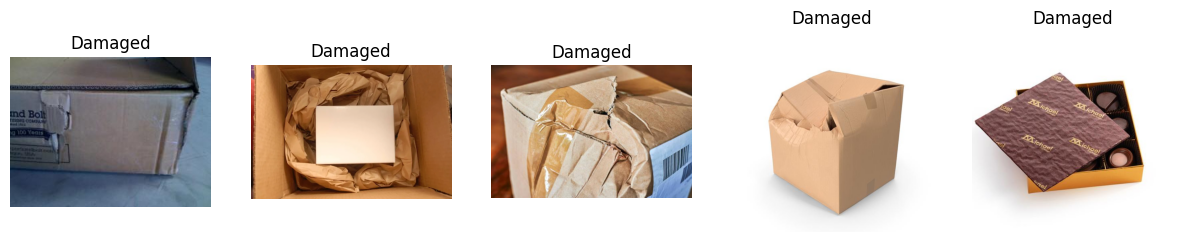

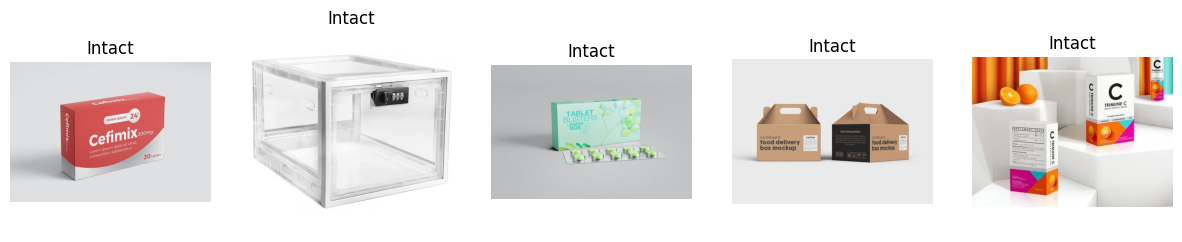

In [4]:
def show_samples(folder, title):
    
    images = os.listdir(folder)
    
    sample_images = random.sample(images, 5)

    plt.figure(figsize=(15,4))

    for i, image_name in enumerate(sample_images):

        img = Image.open(os.path.join(folder, image_name))

        plt.subplot(1,5,i+1)
        plt.imshow(img)
        plt.title(title)
        plt.axis("off")

    plt.show()

show_samples(damaged_path,"Damaged")
show_samples(intact_path,"Intact")

In [5]:
IMG_SIZE = (224,224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    
    rescale=1./255,

    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,

    zoom_range=0.2,

    horizontal_flip=True,

    validation_split=0.2
)

test_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

In [6]:
train_generator = train_datagen.flow_from_directory(
    
    base_path,

    target_size=IMG_SIZE,

    batch_size=BATCH_SIZE,

    class_mode="binary",

    subset="training",

    shuffle=True
)

Found 467 images belonging to 2 classes.


In [7]:
val_generator = test_datagen.flow_from_directory(
    
    base_path,

    target_size=IMG_SIZE,

    batch_size=BATCH_SIZE,

    class_mode="binary",

    subset="validation",

    shuffle=False
)

Found 115 images belonging to 2 classes.


In [8]:
test_generator = test_datagen.flow_from_directory(
    
    base_path,

    target_size=IMG_SIZE,

    batch_size=BATCH_SIZE,

    class_mode="binary",

    subset="validation",

    shuffle=False
)

Found 115 images belonging to 2 classes.


In [9]:
print(train_generator.class_indices)

{'damaged': 0, 'intact': 1}


In [10]:
cnn_model = Sequential([

    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(224,224,3)
    ),

    MaxPooling2D(2,2),

    Conv2D(
        64,
        (3,3),
        activation='relu'
    ),

    MaxPooling2D(2,2),

    Conv2D(
        128,
        (3,3),
        activation='relu'
    ),

    MaxPooling2D(2,2),

    Flatten(),

    Dense(
        128,
        activation='relu'
    ),

    Dropout(0.5),

    Dense(
        1,
        activation='sigmoid'
    )
])

cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-06-07 10:24:21.005686: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
cnn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [12]:
history_cnn = cnn_model.fit(
    
    train_generator,

    validation_data=val_generator,

    epochs=10
)

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


15/15 ━━━━━━━━━━━━━━━━━━━━ 31s 2s/step - accuracy: 0.5375 - loss: 0.9911 - val_accuracy: 0.4696 - val_loss: 0.7618
Epoch 2/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 28s 2s/step - accuracy: 0.6274 - loss: 0.6349 - val_accuracy: 0.6696 - val_loss: 0.6218
Epoch 3/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 27s 2s/step - accuracy: 0.7537 - loss: 0.5301 - val_accuracy: 0.7304 - val_loss: 0.5796
Epoch 4/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 28s 2s/step - accuracy: 0.7709 - loss: 0.4697 - val_accuracy: 0.6957 - val_loss: 0.6415
Epoch 5/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 28s 2s/step - accuracy: 0.7859 - loss: 0.4533 - val_accuracy: 0.7217 - val_loss: 0.5956
Epoch 6/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 27s 2s/step - accuracy: 0.7901 - loss: 0.4424 - val_accuracy: 0.7565 - val_loss: 0.5197
Epoch 7/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 27s 2s/step - accuracy: 0.7752 - loss: 0.4734 - val_accuracy: 0.7130 - val_loss: 0.5107
Epoch 8/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step - accuracy: 0.7559 - loss: 0.4944 - val_accuracy: 0.7217 - val_loss: 0.6020
Epo

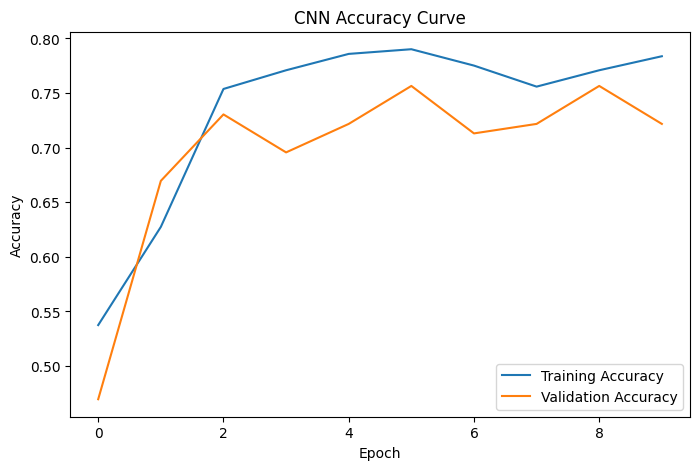

In [13]:
plt.figure(figsize=(8,5))

plt.plot(
    history_cnn.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history_cnn.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title("CNN Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()

plt.savefig("cnn_accuracy_curve.png")

plt.show()

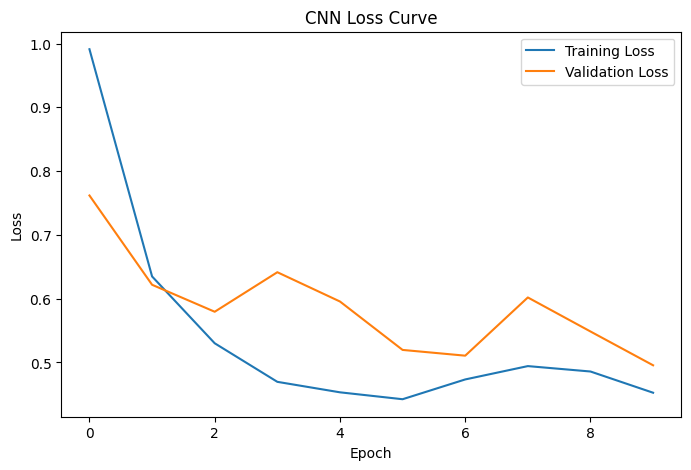

In [14]:
plt.figure(figsize=(8,5))

plt.plot(
    history_cnn.history['loss'],
    label='Training Loss'
)

plt.plot(
    history_cnn.history['val_loss'],
    label='Validation Loss'
)

plt.title("CNN Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()

plt.savefig("cnn_loss_curve.png")

plt.show()

In [16]:
val_generator.reset()

y_pred_prob = cnn_model.predict(val_generator)

y_pred = (
    y_pred_prob > 0.5
).astype(int).flatten()

y_true = val_generator.classes

4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 417ms/step


In [17]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=['damaged','intact']
    )
)

              precision    recall  f1-score   support

     damaged       0.68      0.78      0.72        54
      intact       0.77      0.67      0.72        61

    accuracy                           0.72       115
   macro avg       0.73      0.72      0.72       115
weighted avg       0.73      0.72      0.72       115



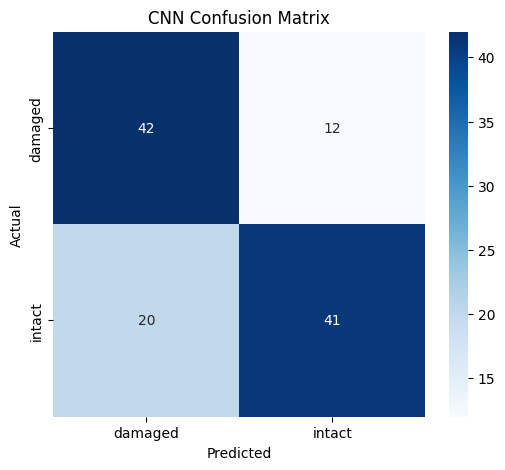

In [18]:
cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['damaged','intact'],
    yticklabels=['damaged','intact']
)

plt.title("CNN Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig("cnn_confusion_matrix.png")

plt.show()

In [19]:
base_model = MobileNetV2(

    weights='imagenet',

    include_top=False,

    input_shape=(224,224,3)
)

base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [25]:
x = base_model.output

x = GlobalAveragePooling2D()(x)

x = Dropout(0.3)(x)

x = Dense(
    128,
    activation='relu'
)(x)

x = Dropout(0.3)(x)

output = Dense(
    1,
    activation='sigmoid'
)(x)

tl_model = Model(
    inputs=base_model.input,
    outputs=output
)

tl_model.compile(
    
    optimizer='adam',

    loss='binary_crossentropy',

    metrics=['accuracy']
)

In [26]:
history_tl = tl_model.fit(
    
    train_generator,

    validation_data=val_generator,

    epochs=10
)

Epoch 1/10
 2/15 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.3828 - loss: 0.9816 

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


15/15 ━━━━━━━━━━━━━━━━━━━━ 24s 1s/step - accuracy: 0.7173 - loss: 0.5260 - val_accuracy: 0.7043 - val_loss: 0.5597
Epoch 2/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step - accuracy: 0.8694 - loss: 0.3145 - val_accuracy: 0.6957 - val_loss: 0.6687
Epoch 3/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step - accuracy: 0.8929 - loss: 0.2852 - val_accuracy: 0.7913 - val_loss: 0.4265
Epoch 4/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step - accuracy: 0.8951 - loss: 0.2319 - val_accuracy: 0.7652 - val_loss: 0.4406
Epoch 5/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step - accuracy: 0.9208 - loss: 0.2255 - val_accuracy: 0.8435 - val_loss: 0.4075
Epoch 6/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step - accuracy: 0.8951 - loss: 0.2299 - val_accuracy: 0.7304 - val_loss: 0.5196
Epoch 7/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.9101 - loss: 0.2340 - val_accuracy: 0.6870 - val_loss: 0.7353
Epoch 8/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step - accuracy: 0.9208 - loss: 0.1877 - val_accuracy: 0.7043 - val_loss: 0.6791
Epo

In [27]:
loss_tl, acc_tl = tl_model.evaluate(
    val_generator
)

print("MobileNetV2 Accuracy:", acc_tl)

4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 554ms/step - accuracy: 0.7565 - loss: 0.5167
MobileNetV2 Accuracy: 0.7565217614173889


In [28]:
y_pred_prob_tl = tl_model.predict(
    val_generator
)

y_pred_tl = (
    y_pred_prob_tl > 0.5
).astype(int).flatten()

print(
    classification_report(
        y_true,
        y_pred_tl,
        target_names=['damaged','intact']
    )
)

4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 931ms/step
              precision    recall  f1-score   support

     damaged       0.68      0.91      0.78        54
      intact       0.88      0.62      0.73        61

    accuracy                           0.76       115
   macro avg       0.78      0.77      0.75       115
weighted avg       0.79      0.76      0.75       115



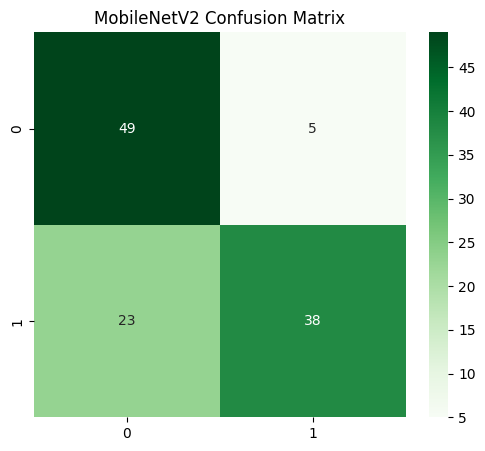

In [29]:
cm_tl = confusion_matrix(
    y_true,
    y_pred_tl
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_tl,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title("MobileNetV2 Confusion Matrix")

plt.savefig(
    "mobilenet_confusion_matrix.png"
)

plt.show()

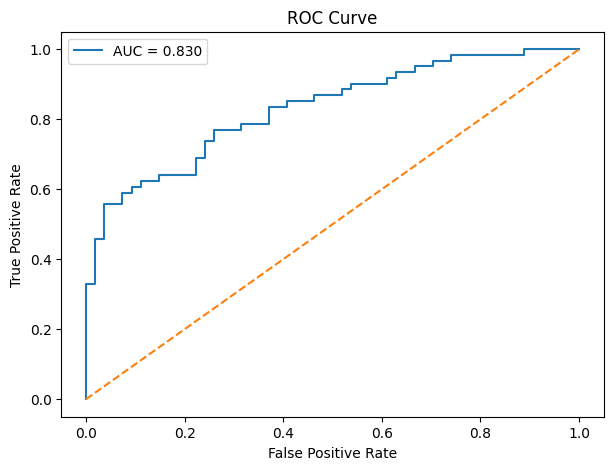

In [30]:
fpr, tpr, _ = roc_curve(
    y_true,
    y_pred_prob
)

roc_auc = auc(
    fpr,
    tpr
)

plt.figure(figsize=(7,5))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc:.3f}"
)

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.savefig("roc_curve.png")

plt.show()

In [31]:
cnn_acc = max(
    history_cnn.history['val_accuracy']
)

mobilenet_acc = max(
    history_tl.history['val_accuracy']
)

comparison = pd.DataFrame({

    "Model":[
        "CNN",
        "MobileNetV2"
    ],

    "Best Validation Accuracy":[
        cnn_acc,
        mobilenet_acc
    ]
})

comparison

,Model,Best Validation Accuracy
0,CNN,0.756522
1,MobileNetV2,0.843478


In [32]:
incorrect = np.where(
    y_true != y_pred
)[0]

print(
    "Misclassified Images:",
    len(incorrect)
)

Misclassified Images: 32
